In [3]:
import os
print(os.getcwd())

C:\Users\makth\Desktop\UAV_ML_Project\04_Python_Code


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the real flight data - full path
df = pd.read_csv(r'C:\Users\makth\Desktop\UAV_ML_Project\02_Dataset\sensor_accel.csv')

#  what columns we have
print("Columns:", df.columns.tolist())
print("Total rows:", len(df))
df.head()

Columns: ['timestamp', 'timestamp_sample', 'device_id', 'x', 'y', 'z', 'temperature', 'error_count', 'clip_counter[0]', 'clip_counter[1]', 'clip_counter[2]', 'samples']
Total rows: 1185


,timestamp,timestamp_sample,device_id,x,y,z,temperature,error_count,clip_counter[0],clip_counter[1],clip_counter[2],samples
0,781755728,781755467,3670050,-0.734541,-0.015323,-9.520782,30.552020,0,0,0,0,5
1,782757276,782757110,3670050,-0.672292,0.098641,-9.512642,30.625460,0,0,0,0,5
2,783757823,783757647,3670050,-0.612916,-0.203028,-9.763555,30.532436,0,0,0,0,5
3,784755800,784755636,3670050,-0.698628,0.080924,-9.458055,30.576500,0,0,0,0,5
4,785756311,785756146,3670050,-0.684742,-0.246124,-9.559568,30.586292,0,0,0,0,5


In [5]:
# UAV mass in kg
UAV_MASS = 1.5

# Convert acceleration to forces (F = m x a)
# Note: z is negative because sensor faces down - so we flip it
df['Fx'] = UAV_MASS * df['x']
df['Fy'] = UAV_MASS * df['y']
df['Fz'] = UAV_MASS * (abs(df['z']) - 9.81)

# Find worst case loads
max_thrust  = df['Fz'].max()
max_lateral = df['Fx'].abs().max()

print("=== YOUR FEA LOADS ===")
print(f"Max Thrust  (Fz): {max_thrust:.2f} N")
print(f"Max Lateral (Fx): {max_lateral:.2f} N")
print("======================")
print("Write these numbers down - they go into SOLIDWORKS!")

=== YOUR FEA LOADS ===
Max Thrust  (Fz): 50.91 N
Max Lateral (Fx): 25.90 N
Write these numbers down - they go into SOLIDWORKS!


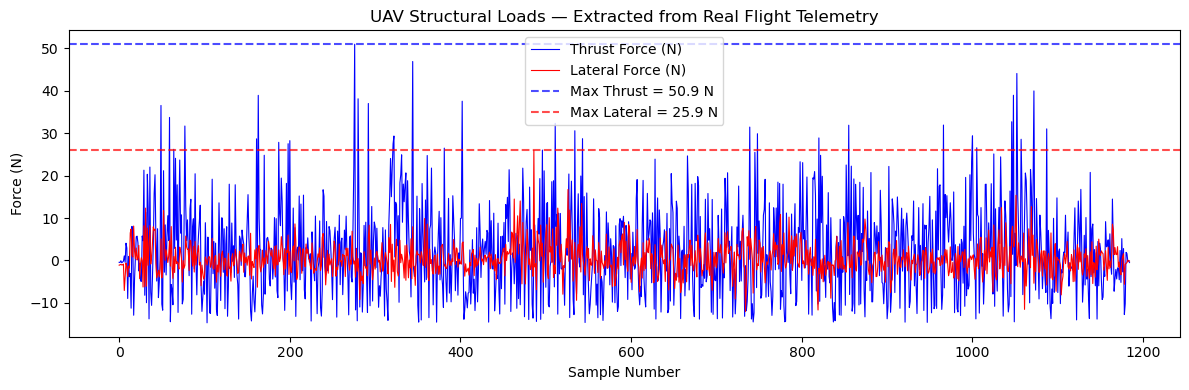

✅ Graph saved to Portfolio folder!


In [6]:
# Plot and save
plt.figure(figsize=(12, 4))
plt.plot(df.index, df['Fz'], color='blue', label='Thrust Force (N)', linewidth=0.8)
plt.plot(df.index, df['Fx'], color='red',  label='Lateral Force (N)', linewidth=0.8)
plt.axhline(y=max_thrust,  color='blue', linestyle='--', alpha=0.7, label=f'Max Thrust = {max_thrust:.1f} N')
plt.axhline(y=max_lateral, color='red',  linestyle='--', alpha=0.7, label=f'Max Lateral = {max_lateral:.1f} N')
plt.legend()
plt.title('UAV Structural Loads — Extracted from Real Flight Telemetry')
plt.xlabel('Sample Number')
plt.ylabel('Force (N)')
plt.tight_layout()
plt.savefig(r'C:\Users\makth\Desktop\UAV_ML_Project\06_Portfolio\flight_loads_plot.png', dpi=150)
plt.show()
print("✅ Graph saved to Portfolio folder!")